In [2]:
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from albumentations import Compose, Resize, Normalize
from albumentations.pytorch import ToTensorV2
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [3]:
class CollisionPredictor(nn.Module):
    """
    MobileNetV3-Large backbone extracts per-frame features.
    LSTM captures temporal patterns across the 16-frame window.
    This is the architecture you trained — must match exactly.
    """
    def __init__(self, num_frames=16, lstm_hidden=256):
        super().__init__()
        self.backbone = mobilenet_v3_large(weights=None)   # weights loaded from .pth below
        backbone_out = self.backbone.classifier[0].in_features   # 960
        self.backbone.classifier = nn.Identity()

        self.lstm = nn.LSTM(backbone_out, lstm_hidden, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (batch, frames, C, H, W)
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        features = self.backbone(x).view(b, t, -1)   # MobileNetV3 per-frame features
        lstm_out, _ = self.lstm(features)             # LSTM over time
        return self.classifier(lstm_out[:, -1, :]).squeeze(-1)

print("CollisionPredictor class defined (MobileNetV3-Large + LSTM)")


CollisionPredictor class defined (MobileNetV3-Large + LSTM)


In [4]:
# ✏️ Change MODEL_PATH to whichever checkpoint you want to test
# From your folder screenshot, you have:
#   best_finetuned.pth      ← try this first (most recent fine-tune, 16,819 KB)
#   collision_model.pth     ← initial training (16,819 KB)
#   mobilenetv3_collision.pth ← earlier (16,630 KB)

MODEL_PATH = r"C:\Users\soham\finalproject\collision\best_finetuned.pth"

model = CollisionPredictor(lstm_hidden=256).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"✅ Model loaded from: {MODEL_PATH}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


✅ Model loaded from: C:\Users\soham\finalproject\collision\best_finetuned.pth
   Parameters: 4,252,209


Video: 3026 frames @ 30 fps


Diagnosing: 100%|██████████████████████████████████████████████████████████████████| 3026/3026 [00:51<00:00, 58.62it/s]


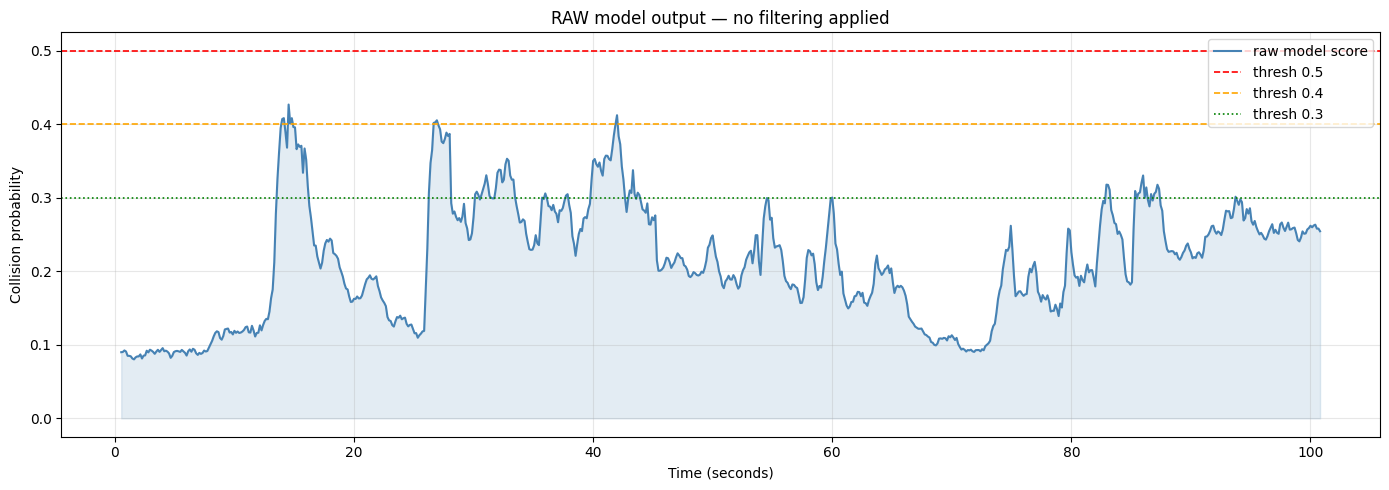


📊 Results:
   Peak score : 0.4268  at t = 14.5s
   Above 0.50 : 0 inference calls
   Above 0.40 : 9 inference calls
   Above 0.30 : 104 inference calls

✅ RECOMMENDED thresholds:
   high_thresh = 0.36
   low_thresh  = 0.26


In [5]:
def diagnose_video(video_path, model, device, stride=4):
    """
    Plots raw model output over time with NO filtering.
    Look at the plot to find:
      - Does the score peak at the accident moment?
      - What is the peak score? (use peak - 0.07 as high_thresh)
    """
    transform = Compose([
        Resize(224, 224),
        Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2(),
    ])

    cap   = cv2.VideoCapture(video_path)
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Video: {total} frames @ {fps:.0f} fps")

    ring      = deque(maxlen=16)
    scores    = []
    times     = []
    frame_idx = 0

    model.eval()
    pbar = tqdm(total=total, desc="Diagnosing")

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        ring.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        if frame_idx % stride == 0 and len(ring) == 16:
            tensor = torch.stack(
                [transform(image=img)["image"] for img in ring]
            ).unsqueeze(0).to(device)
            with torch.no_grad():
                score = torch.sigmoid(model(tensor)).item()
            scores.append(score)
            times.append(frame_idx / fps)

        frame_idx += 1
        pbar.update(1)

    cap.release()
    pbar.close()

    # Plot
    plt.figure(figsize=(14, 5))
    plt.plot(times, scores, color="steelblue", lw=1.5, label="raw model score")
    for thresh, color, ls in [(0.5,"red","--"),(0.4,"orange","--"),(0.3,"green",":")]:
        plt.axhline(thresh, color=color, ls=ls, lw=1.2, label=f"thresh {thresh}")
    plt.fill_between(times, scores, alpha=0.15, color="steelblue")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Collision probability")
    plt.title("RAW model output — no filtering applied")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("score_diagnostic.png", dpi=150)
    plt.show()

    if scores:
        peak      = max(scores)
        peak_time = times[scores.index(peak)]
        print(f"\n📊 Results:")
        print(f"   Peak score : {peak:.4f}  at t = {peak_time:.1f}s")
        print(f"   Above 0.50 : {sum(s>0.50 for s in scores)} inference calls")
        print(f"   Above 0.40 : {sum(s>0.40 for s in scores)} inference calls")
        print(f"   Above 0.30 : {sum(s>0.30 for s in scores)} inference calls")
        print(f"\n✅ RECOMMENDED thresholds:")
        print(f"   high_thresh = {max(peak-0.07, 0.20):.2f}")
        print(f"   low_thresh  = {max(peak-0.17, 0.12):.2f}")
    else:
        print("No scores collected — video too short or stride too large")

    return scores, times

# ── Run on your video ────────────────────────────────────────────────────────
VIDEO_PATH = r"C:\Users\soham\finalproject\collision\videoplayback.mp4"
scores, times = diagnose_video(VIDEO_PATH, model, device)
run_fixed_inference(
    VIDEO_PATH,
    model,
    device,
    output_path="final_output.mp4"
)

In [6]:
def run_fixed_inference(
    video_path,
    model,
    device,
    output_path          = "output_fixed.mp4",
    window_frames        = 16,
    stride               = 4,
    high_thresh          = 0.33,   # ← set from diagnostic output above
    low_thresh           = 0.25,
    min_confirm_calls    = 8,      # 8 model calls x stride4 / 30fps ≈ 1 second
    hold_calls           = 5,
    flow_low_thresh      = 0.8,
    edge_thresh          = 0.25,
    scene_override_score = 0.38,   # scene filter disabled above this score
):
    transform = Compose([
        Resize(224, 224),
        Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2(),
    ])

    cap   = cv2.VideoCapture(video_path)
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"{W}x{H} @ {fps:.0f}fps | {total} frames | {device}")

    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

    frame_ring      = deque(maxlen=window_frames)
    ema_score       = 0.0
    ema_alpha       = 0.4
    consecutive_hot = 0
    alert_active    = False
    hold_countdown  = 0
    prev_gray       = None
    frame_idx       = 0

    pbar = tqdm(total=total, desc="Processing")

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_ring.append(frame_bgr)

        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        flow_mag = 0.0
        if prev_gray is not None:
            flow     = cv2.calcOpticalFlowFarneback(prev_gray, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
            flow_mag = float(np.mean(np.linalg.norm(flow, axis=2)))
        prev_gray = gray

        edges        = cv2.Canny(gray, 60, 150)
        edge_density = np.count_nonzero(edges) / edges.size

        scene_blocked = (
            ema_score < scene_override_score
            and flow_mag < flow_low_thresh
            and edge_density > edge_thresh
        )

        if frame_idx % stride == 0 and len(frame_ring) == window_frames:
            if not scene_blocked:
                clip_rgb = [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frame_ring]
                tensor   = torch.stack(
                    [transform(image=img)["image"] for img in clip_rgb]
                ).unsqueeze(0).to(device)
                with torch.no_grad():
                    raw = torch.sigmoid(model(tensor)).item()
                ema_score = ema_alpha * raw + (1 - ema_alpha) * ema_score
            else:
                ema_score *= 0.92

            if ema_score >= high_thresh:
                consecutive_hot += 1
            else:
                consecutive_hot = max(0, consecutive_hot - 1)

            if not alert_active:
                if consecutive_hot >= min_confirm_calls:
                    alert_active   = True
                    hold_countdown = hold_calls
            else:
                if hold_countdown > 0:
                    hold_countdown -= 1
                elif ema_score < low_thresh:
                    alert_active    = False
                    consecutive_hot = 0

        confirm_pct = min(consecutive_hot / max(min_confirm_calls, 1), 1.0)
        out_frame   = frame_bgr.copy()

        if alert_active:
            overlay = out_frame.copy()
            cv2.rectangle(overlay, (0,0), (W,H), (0,0,220), -1)
            cv2.addWeighted(overlay, 0.35, out_frame, 0.65, 0, out_frame)
            cv2.rectangle(out_frame, (0,0), (W-1,H-1), (0,0,255), 6)
            cv2.putText(out_frame, f"COLLISION  {ema_score:.0%}",
                        (20,60), cv2.FONT_HERSHEY_DUPLEX, 1.4, (255,255,255), 3)
            cv2.putText(out_frame, f"COLLISION  {ema_score:.0%}",
                        (20,60), cv2.FONT_HERSHEY_DUPLEX, 1.4, (0,0,200), 1)

        elif not scene_blocked and confirm_pct > 0.1:
            bw     = int(W * 0.35)
            filled = int(bw * confirm_pct)
            cv2.rectangle(out_frame, (15,15), (15+bw,33), (60,60,60), -1)
            g = int(200*(1-confirm_pct)); r = int(255*confirm_pct)
            cv2.rectangle(out_frame, (15,15), (15+filled,33), (0,g,r), -1)
            cv2.rectangle(out_frame, (15,15), (15+bw,33), (200,200,200), 1)
            cv2.putText(out_frame, f"Risk: {ema_score:.0%}",
                        (15,50), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (220,220,220), 1)

        if scene_blocked:
            cv2.rectangle(out_frame, (10,10), (390,36), (40,40,40), -1)
            cv2.putText(out_frame, "TRAFFIC - alert suppressed",
                        (14,30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (160,160,160), 1)

        cv2.putText(out_frame, f"{ema_score:.2f}",
                    (W-75, H-12), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200,200,200), 1)

        out.write(out_frame)
        del out_frame
        frame_idx += 1
        pbar.update(1)

    pbar.close(); cap.release(); out.release()
    print(f"Done -> {os.path.abspath(output_path)}")

# ── Run ──────────────────────────────────────────────────────────────────────
VIDEO_PATH  = r"C:\Users\soham\finalproject\collision\videoplayback.mp4"
OUTPUT_PATH = r"C:\Users\soham\finalproject\collision\output_fixed.mp4"

run_fixed_inference(
    video_path           = VIDEO_PATH,
    model                = model,
    device               = device,
    output_path          = OUTPUT_PATH,
    stride               = 4,
    high_thresh          = 0.33,   # ← update from Cell 4 diagnostic output
    low_thresh           = 0.25,
    min_confirm_calls    = 8,
    scene_override_score = 0.38,
)


640x360 @ 30fps | 3026 frames | cuda


Processing: 100%|██████████████████████████████████████████████████████████████████| 3026/3026 [09:25<00:00,  5.35it/s]


Done -> C:\Users\soham\finalproject\collision\output_fixed.mp4


NameError: name 'collision' is not defined